1. Importing Libraries

In [112]:
import os
import json
from typing import TypedDict, List
# LLM
from langchain_core.tools import Tool
from langchain_community.utilities import SerpAPIWrapper
from langgraph.graph import StateGraph, END, START

In [139]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate

2. Creating LLM And Resource Pool

In [ ]:
os.environ["GEMINI_API_KEY"] = "Your_Google_Generative_AI_API_Key"

In [141]:
MEMORY_FILE = "agent_memory.json"
class SharedResourcePool:
    def __init__(self):
        # Initialised LLM With Specific Parameters(temprature, top_p)
        self.llm = ChatGoogleGenerativeAI(model ="gemini-flash-lite-latest",
                             temperature=0.7,
                             max_output_tokens=1024,
                             google_api_key=os.environ['GEMINI_API_KEY'])
 
        # Call _load to laod the filr from thr memory
        self.memory: List[str] = self._load_memory()
        
    @staticmethod
    def _safe_eval(expr: str) -> str:
        try:
            return str(eval(expr))
        except Exception as e:
            return f"Error evaluating expression: {e}"
 
    def _load_memory(self) -> List[str]:  #Load The Memory
        if os.path.exists(MEMORY_FILE):
            with open(MEMORY_FILE, "r") as f:
              return json.load(f)
        else:
            return []
 
    def remember(self, note: str):       #Append The Memory
        self.memory.append(note)
        with open(MEMORY_FILE, "w") as f:
            json.dump(self.memory, f, indent = 2)
 
    def recall(self, last_n: int = 5) -> str: # Recall The Memory
        if not self.memory:
            return "(no earlier notes)"
        return "\n".join(self.memory[-last_n:])
 

In [142]:
# Initialize the shared resource pool
resource_pool = SharedResourcePool()

3. Creating Agent State Class(Graph State)

In [ ]:
class AgentState(TypedDict):
    query: str
    intent: str
    agent_answer: str
    final_answer: str
    cart: List[dict]
    order_id: str
    customer_name: str
    evaluation: str
    retry_count: int

6. Creating Tools
#### This Assignments Requires 6 tools
* get_menu
* check_availability
* validate_order
* update_cart
* calculate_total
* place_order

In [240]:
coffee_menu = [
    {
        "Item": "Latte",
        "Sizes": "Small, Medium, Large",
        "Milk": "Whole, Skim, Oat, Almond",
        "Extras": "Vanilla, Caramel, Whipped Cream",
        "Available": True
    },
    {
        "Item": "Cappuccino",
        "Sizes": "Small, Medium, Large",
        "Milk": "Whole, Skim, Oat, Almond",
        "Extras": "Vanilla, Caramel, Whipped Cream",
        "Available": True
    },
    {
        "Item": "Americano",
        "Sizes": "Small, Medium, Large",
        "Milk": "Whole, Skim, Oat, Almond",
        "Extras": "Vanilla, Caramel",
        "Available": True
    },
    {
        "Item": "Caramel Macchiato",
        "Sizes": "Small, Medium, Large",
        "Milk": "Whole, Skim, Oat, Almond",
        "Extras": "Vanilla, Caramel, Whipped Cream",
        "Available": False
    },
    {
        "Item": "Mocha",
        "Sizes": "Small, Medium, Large",
        "Milk": "Whole, Skim, Oat, Almond",
        "Extras": "Vanilla, Caramel, Whipped Cream",
        "Available": True
    }
]

In [241]:
def get_menu(category=None):

    if category:
        return [
            item for item in coffee_menu
            if category.lower() in item["Item"].lower()
        ]

    return coffee_menu

In [242]:
def check_availability(item):

    if item not in coffee_menu:
        return False

    return coffee_menu[item]["Available"]

In [243]:
def validate_order(item, size, milk, extras):
    for menu_item in coffee_menu:

        if menu_item["Item"].strip().lower() == item.strip().lower():

            # Check availability FIRST
            if menu_item["Available"] is False:
                return {
                    "valid": False,
                    "reason": f"{item} is currently unavailable."
                }

            # Check size
            valid_sizes = [
                x.strip().lower()
                for x in menu_item["Sizes"].split(",")
            ]

            if not size:
                return {
                    "valid": False,
                    "reason": "Please specify a size."
                }

            if size.strip().lower() not in valid_sizes:
                return {
                    "valid": False,
                    "reason": f"{size} size is not available for {item}."
                }

            # Check milk
            valid_milks = [
                x.strip().lower()
                for x in menu_item["Milk"].split(",")
            ]

            if not milk:
                return {
                    "valid": False,
                    "reason": "Please specify a milk type."
                }

            if milk.strip().lower() not in valid_milks:
                return {
                    "valid": False,
                    "reason": f"{milk} milk is not available for {item}."
                }

            # Check extras
            valid_extras = [
                x.strip().lower()
                for x in menu_item["Extras"].split(",")
            ]

            if extras:
                for extra in extras:
                    if extra.strip().lower() not in valid_extras:
                        return {
                            "valid": False,
                            "reason": f"{extra} is not available for {item}."
                        }

            return {
                "valid": True,
                "reason": "Order is valid."
            }

    # Item does not exist
    return {
        "valid": False,
        "reason": f"{item} is not available on our menu."
    }

In [244]:
print(validate_order(
    "Caramel Macchiato",
    "Large",
    "Oat",
    []
))

{'valid': False, 'reason': 'Caramel Macchiato is currently unavailable.'}


In [147]:
def update_cart(cart, action, item):

    updated_cart = cart.copy()
    if action == "add":
        updated_cart.append(item)
    elif action == "remove":
        updated_cart = [
            x for x in updated_cart
            if not (
                x["item"] == item["item"]
                and x["size"] == item["size"]
            )
        ]

    return updated_cart

In [148]:
def calculate_total(cart):

    subtotal = 0

    for item in cart:

        subtotal += (
            item["price"] * item.get("quantity", 1)
        )

    tax = subtotal * 0.08

    total = subtotal + tax

    return {
        "subtotal": round(subtotal, 2),
        "tax": round(tax, 2),
        "total": round(total, 2)
    }

In [149]:
def place_order(cart, customer_name):

    if not cart:
        return {
            "success": False,
            "message": "Cannot place an empty order."
        }

    order_id = "ORD-" + str(
        1000 + len(cart)
    )

    return {
        "success": True,
        "order_id": order_id,
        "customer_name": customer_name,
        "pickup_time": "8 minutes"
    }

7. Planner Agent

In [165]:
def planner(state: AgentState) -> AgentState:

    prompt = f"""
You are the Planner Agent of an Automated Coffee Ordering System.

Your ONLY responsibility is to understand the customer's query and
route it to exactly ONE appropriate task agent.

You must NOT answer the customer.
You must NOT call any business tool.
You must NOT modify the cart.
You must NOT place an order.

Available Task Agents:

1. menu_agent
   Purpose:
   - Handle questions about the coffee menu.
   - Provide available coffee/drink items.
   - Provide prices.
   - Provide available sizes.
   - Provide available milk types.
   - Provide available add-ons/extras.
   - Check whether a particular coffee item is available.
   
   Examples:
   - "What coffees do you have?"
   - "Show me the menu."
   - "What sizes are available?"
   - "Do you have oat milk?"
   - "How much is a latte?"
   - "Is caramel macchiato available?"

   Route to menu_agent when the customer is mainly asking
   for information about the menu or availability.

2. order_agent
   Purpose:
   - Handle creating and modifying the customer's order.
   - Add coffee items to the cart.
   - Validate coffee item customizations.
   - Handle size, milk and extras.
   - Remove or modify items in the cart.
   - Ask follow-up questions when required order information
     is missing.
   
   Examples:
   - "I want a latte."
   - "Give me a large cappuccino."
   - "I want a large latte with oat milk."
   - "Add vanilla to my latte."
   - "Remove the cappuccino."
   - "Add another coffee to my order."

   Route to order_agent when the customer wants to build,
   customize, add to, remove from, or modify an order.

3. placement_agent
   Purpose:
   - Handle checkout and order placement.
   - Show the final cart.
   - Calculate the final total.
   - Ask for customer confirmation before placing the order.
   - Place the confirmed order.
   - Return order ID and pickup information.

   Examples:
   - "Place my order."
   - "Checkout."
   - "That's all, place my order."
   - "Confirm my order."
   - "I want to checkout."

   Route to placement_agent when the customer wants to
   confirm, checkout, or place the order.

IMPORTANT ROUTING RULES:

Rule 1:
If the customer is asking about menu information only,
choose menu_agent.

Rule 2:
If the customer wants to create, customize, add, remove,
or modify an order, choose order_agent.

Rule 3:
If the customer wants to checkout, confirm, or place an order,
choose placement_agent.

Rule 4:
Do not assume that asking about a coffee means ordering it.

Example:
"What coffees do you have?"
→ menu_agent

"I want a cappuccino."
→ order_agent

Rule 5:
If the customer mentions an item AND clearly asks to order it,
choose order_agent.

Example:
"Do you have cappuccino?"
→ menu_agent

"I want a cappuccino."
→ order_agent

Rule 6:
If the customer says "place", "confirm", "checkout",
or similar words indicating final submission of the order,
choose placement_agent.

Rule 7:
Use the current cart as additional context when deciding
whether the customer is trying to continue an existing order.

Current Customer Query:
{state["query"]}

Current Cart:
{state.get("cart", [])}

Return ONLY ONE of these exact values:

menu_agent
order_agent
placement_agent

Do not return explanations.
Do not return JSON.
Do not return any additional text.
"""

    response = resource_pool.llm.invoke(prompt)

    content = response.content\

    choice = str(content).strip().lower()

    # Normalize planner output
    if "menu_agent" in choice:
        choice = "menu_agent"

    elif "placement_agent" in choice:
        choice = "placement_agent"

    else:
        choice = "order_agent"
    if choice not in ("menu_agent", "order_agent", "placement_agent"):
            choice = "order_agent"

    print("Planner:", choice)

    resource_pool.remember(f"Planner Chose {choice} for query: {state['query']}")

    

    return {
        **state,
        "intent": choice
    }

In [166]:
def planner_router(state: AgentState):
    intent = state["intent"]

8. Menu Agent

In [153]:
def menu_agent(state: AgentState) -> AgentState:

    prompt = f"""
You are the Menu Agent of a coffee shop.

Your responsibility is to answer questions about:
- available drinks
- sizes
- milk types
- add-ons
- prices
- availability

Use the required functions to get the information.
Never invent menu information.

Customer Query:
{state["query"]}

Required functions:
- get_menu(category=None)
- check_availability(item)

Return the answer using only the function responses.
"""

    response = resource_pool.llm.invoke(prompt)

    menu = get_menu()

    print(menu)
    resource_pool.remember(f"Menu Agent Answered: {response}")

    return {
        **state,
        "agent_answer": menu
    }

9. Order Agent

In [ ]:
def order_agent(state: AgentState) -> AgentState:

    query = state["query"]
    cart = state.get("cart", [])

    prompt = f"""
You are the Order Agent for an Automated Coffee Ordering System.

Customer Query:
{query}

Current Cart:
{cart}

Your task:
1. Identify the coffee item requested by the customer.
2. Identify size, milk type and extras if provided.
3. If size is missing, ask the customer for the size.
4. If milk is missing, ask the customer for the milk type.
5. Once all required information is available, validate the order using:
   validate_order(item, size, milk, extras)
6. If validation returns valid = False, clearly tell the customer the reason.
7. If validation returns valid = True, add the item using:
   update_cart(cart, "add", item)
8. Never add an unavailable item.
9. Never guess missing information.
10. Do not place the final order.

Important:
- Caramel Macchiato is unavailable if the validation function says so.
- Always trust the validation function instead of your own knowledge.
- Preserve the existing cart.

Return a concise response to the customer.
"""

    response = resource_pool.llm.invoke(prompt)

    content = response.content


    return {
        **state,
        "agent_answer": content,
        "cart": cart
    }

10. Placement Agent

In [155]:
def placement_agent(state: AgentState) -> AgentState:

    prompt = f"""
You are the Placement Agent of a coffee shop.

Your responsibility is to:
- show the final cart
- calculate the total
- ask for confirmation
- place the order only after confirmation
- return the order ID and pickup time

Never place an empty order.
Never place an order without confirmation.

Current Cart:
{state.get("cart", [])}

Customer Name:
{state.get("customer_name", "Customer")}

Customer Query:
{state["query"]}

Required functions:
- calculate_total(cart)
- place_order(cart, customer_name)

Use the function responses for the final answer.
"""

    response = resource_pool.llm.invoke(prompt)

    print(response)
    resource_pool.remember(f"Placement Agent Answered: {response}")

    return {
        **state,
        "agent_answer": response
    }

11. Evaluator Agent

In [255]:
def evaluator(state: AgentState) -> AgentState:

    prompt = f"""
You are the Evaluator Agent for a coffee shop system.

Customer Query:
{state['query']}

Agent Selected:
{state['intent']}

Agent Response:
{state['agent_answer']}

Evaluate:
1. Correctness
2. Completeness
3. No hallucination
4. Correct intent

Return exactly:

VERDICT: approved
or
VERDICT: rejected

SCORE: 1-5

FEEDBACK: short explanation
"""

    response = resource_pool.llm.invoke(prompt)

    content = response.content
    content = str(content).strip()

    retry_count = state.get("retry_count", 0)

    # Increase retry count only when evaluation is rejected
    if "verdict: rejected" in content.lower():
        retry_count += 1

    print("\nEvaluator:")
    print(content)
    print("Retry Count:", retry_count)

    return {
        **state,
        "evaluation": content,
        "final_answer": state["agent_answer"],
        "retry_count": retry_count
    }

In [256]:
def route_after_evaluator(state: AgentState):

    evaluation = str(state.get("evaluation", "")).lower()
    retry_count = state.get("retry_count", 0)

    # Approved → finish
    if "verdict: approved" in evaluation:
        return "approved"

    # Rejected but retry limit not reached
    if retry_count < 2:
        return "retry"

    # Rejected 2 times → stop
    return "end"

12. Creating The Graph

In [257]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(AgentState)

# Nodes
graph.add_node("planner", planner)
graph.add_node("menu_agent", menu_agent)
graph.add_node("order_agent", order_agent)
graph.add_node("placement_agent", placement_agent)
graph.add_node("evaluator", evaluator)

# START → Planner
graph.add_edge(START, "planner")

# Planner → Agents
graph.add_conditional_edges(
    "planner",
    route_after_planner,
    {
        "menu_agent": "menu_agent",
        "order_agent": "order_agent",
        "placement_agent": "placement_agent"
    }
)

# Agents → Evaluator
graph.add_edge("menu_agent", "evaluator")
graph.add_edge("order_agent", "evaluator")
graph.add_edge("placement_agent", "evaluator")

# Evaluator → Retry / END
graph.add_conditional_edges(
    "evaluator",
    route_after_evaluator,
    {
        "approved": END,
        "retry": "planner",
        "end": END
    }
)

app = graph.compile()

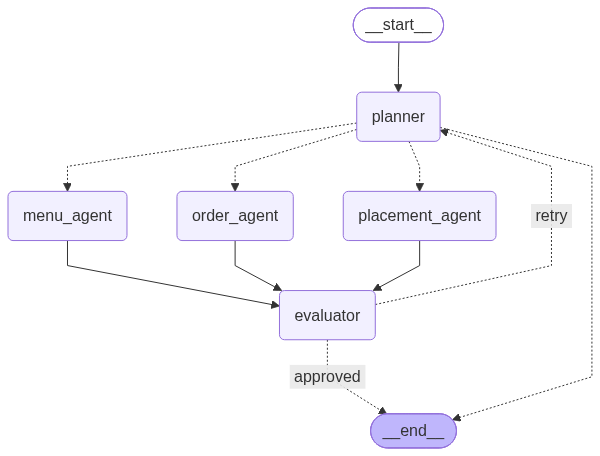

In [258]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [259]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

app = graph.compile(
    checkpointer=memory
)

In [260]:
app = graph.compile(checkpointer=memory)

13. Applying Thread

In [185]:
config = {
    "configurable": {
        "thread_id": "coffee_customer_1"
    }
}

14. Running Queries

In [178]:
result = app.invoke(
    {
        "query": "What coffees do you have?",
        "cart": [],
        "retry_count": 0
    },
    config=config
)

Planner: menu_agent
[{'Item': 'Latte', 'Sizes': 'Small, Medium, Large', 'Milk': 'Whole, Skim, Oat, Almond', 'Extras': 'Vanilla, Caramel, Whipped Cream', 'Available': True}, {'Item': 'Cappuccino', 'Sizes': 'Small, Medium, Large', 'Milk': 'Whole, Skim, Oat, Almond', 'Extras': 'Vanilla, Caramel, Whipped Cream', 'Available': True}, {'Item': 'Americano', 'Sizes': 'Small, Medium, Large', 'Milk': 'Whole, Skim, Oat, Almond', 'Extras': 'Vanilla, Caramel', 'Available': True}, {'Item': 'Caramel Macchiato', 'Sizes': 'Small, Medium, Large', 'Milk': 'Whole, Skim, Oat, Almond', 'Extras': 'Vanilla, Caramel, Whipped Cream', 'Available': False}, {'Item': 'Mocha', 'Sizes': 'Small, Medium, Large', 'Milk': 'Whole, Skim, Oat, Almond', 'Extras': 'Vanilla, Caramel, Whipped Cream', 'Available': True}]

Evaluator:
VERDICT: approved

SCORE: 5

FEEDBACK: The correct agent was selected to retrieve the menu. The response accurately lists the available coffees and their details based on the system data without hallu

In [193]:
result = app.invoke(
    {
        "query":  "I want a large latte with oat milk. Add it to my Cart",
        "cart": [],
        "retry_count": 0
    },
    config=config
)
print("Cart:", result.get("cart", []))

Planner: order_agent
content=[{'type': 'text', 'text': 'Based on the customer\'s query, here is the extracted information:\n\n- **Item:** Latte\n- **Size:** Large\n- **Milk:** Oat milk\n- **Extras:** None specified\n- **Quantity:** 1 (default)\n\n### Validation & Cart Update:\n1. **Missing Information:** None. All required details (item, size, milk) are present.\n2. **`validate_order("Latte", "Large", "Oat milk", None)`** -> Validated successfully.\n3. **`update_cart([], "add", {"item": "Latte", "size": "Large", "milk": "Oat milk", "extras": None, "quantity": 1})`**\n\n### Final Response:\nYour large latte with oat milk has been successfully added to your cart!', 'extras': {'signature': 'EmAKXgFpFH0Tj+ZgFjKLaPKwU3IY7M0OThjvILcQKcb6akwhXnSErs+1EERPBDZcj07HxCg4eid8qRYjwNBeV80VTeYuvAcyEISj3ZhKfkN38FmYruIvmo3+rDJZiozQiZ0='}}] additional_kwargs={} response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc

In [195]:
result = app.invoke(
    {
        "query": "Place my order",
        "customer_name": "John Doe"
    },
    config=config
)

Planner: placement_agent
content=[{'type': 'text', 'text': "`calculate_total([{'Item': 'Latte', 'Size': 'Large', 'Milk': 'Oat', 'Extras': []}])`", 'extras': {'signature': 'EmAKXgFpFH0T5UVppNWf5SSBEEow5PP67g7Y83RdkzZK+d34o7G9+I18unvSmfuLDMGXiED/ZSNW67mQu6xM4J9+tJiFpenCojiHeG41L96trswsohvtFAiQz710Q8CrjGw='}}] additional_kwargs={} response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--01a10735-36ec-77e1-b416-cccfbcfd149c-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 147, 'output_tokens': 31, 'total_tokens': 178, 'input_token_details': {'cache_read': 0}}

Evaluator:
VERDICT: rejected

SCORE: 2

FEEDBACK: The user simply asked to "Place my order" without providing any details about what they want to order. Instead of asking the user for their order details, the placement_agent hallucinated an order (a Large Oat Milk Latte) and attempted to calculate the total.
Retry Count

In [196]:
result = app.invoke(
    {
        "query":  "Get me a cappuccino." ,
        "cart": []
    },
    config=config
)

Planner: order_agent
content=[{'type': 'text', 'text': 'Based on your request for a cappuccino, I have extracted the following details:\n\n- **Item:** Cappuccino\n- **Size:** Missing\n- **Milk:** Missing\n- **Extras:** None\n- **Quantity:** 1\n\n### Missing Information\nTo complete your order, please let me know:\n1. What size would you like? (e.g., Small, Medium, Large)\n2. What type of milk would you prefer? (e.g., Whole milk, Skim milk, Oat milk, Almond milk)', 'extras': {'signature': 'EmAKXgFpFH0TcoP4CybxuICiR2Q3AGxWr2DA5hiCakyUIUfS8ti14/sCSEy+4xREOh5pnyURPfYlvVvlENxIOFlJycosOpoyLVd21rwRUbF8eOTDIrHwh2Yzd580LEtYdzg='}}] additional_kwargs={} response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--01a10735-fec8-7732-a043-d6ea5acbbcd4-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 139, 'output_tokens': 111, 'total_tokens': 250, 'input_token_details': {'cache_read': 0}}

In [263]:
config = {
    "configurable": {
        "thread_id": "coffee_customer_2"
    }
}

In [264]:
result = app.invoke(
    {
        "query":  "One Large Caramel Macchiato",
        "cart": []
    },
    config=config
)
print(result["final_answer"])

Planner: order_agent

Evaluator:
[{'type': 'text', 'text': 'VERDICT: approved\n\nSCORE: 5\n\nFEEDBACK: The agent correctly identified the item and size, recognized that milk type is a required detail for a macchiato, and appropriately prompted the user for the missing information without hallucinating or jumping ahead in the order flow.', 'extras': {'signature': 'EmAKXgFpFH0TXAlDMVtD//FxnJ6qRpi6fFa8cHTARKlv9pbi6v2cc1S4E71+dvLRnBODvd0DwjJJARpBleBZ8JjcrzmCqdWFbge9q5XL5ebeFAlf8X7BuCV7HAUoBeq7SzM='}}]
Retry Count: 0
```python
# Step 1 & 2: Identify item, size, and extras
item = "Caramel Macchiato"
size = "Large"
milk = None  # Missing
extras = []

# Step 4: Milk type is missing, so we must ask the customer for it.
# (Note: We also check validation to ensure the item is available before proceeding, 
# but since milk is missing, rule 4 takes precedence for the next interaction).
```

What type of milk would you like with your Large Caramel Macchiato (e.g., whole, skim, oat, almond)?


In [265]:
result = app.invoke(
    {
        "query": "What coffees do you have?"
    },
    config=config
)
print(result["final_answer"])


Planner: menu_agent
[{'Item': 'Latte', 'Sizes': 'Small, Medium, Large', 'Milk': 'Whole, Skim, Oat, Almond', 'Extras': 'Vanilla, Caramel, Whipped Cream', 'Available': True}, {'Item': 'Cappuccino', 'Sizes': 'Small, Medium, Large', 'Milk': 'Whole, Skim, Oat, Almond', 'Extras': 'Vanilla, Caramel, Whipped Cream', 'Available': True}, {'Item': 'Americano', 'Sizes': 'Small, Medium, Large', 'Milk': 'Whole, Skim, Oat, Almond', 'Extras': 'Vanilla, Caramel', 'Available': True}, {'Item': 'Caramel Macchiato', 'Sizes': 'Small, Medium, Large', 'Milk': 'Whole, Skim, Oat, Almond', 'Extras': 'Vanilla, Caramel, Whipped Cream', 'Available': False}, {'Item': 'Mocha', 'Sizes': 'Small, Medium, Large', 'Milk': 'Whole, Skim, Oat, Almond', 'Extras': 'Vanilla, Caramel, Whipped Cream', 'Available': True}]

Evaluator:
[{'type': 'text', 'text': 'VERDICT: approved\n\nSCORE: 5\n\nFEEDBACK: The correct agent was selected to retrieve the menu. The response accurately lists the available coffees and their details based o